# Brain Tumor MRI Classification using Transfer Learning

**Name:** Avnish Agrawal
**Reg No:** 23BAI10628

**Objective:** Classify brain MRI images into 4 categories (Glioma, Meningioma, No Tumor, Pituitary) using CNN with a target accuracy of 90%.

**Dataset:** Brain Tumor MRI Dataset — 5,600 training images, 1,600 test images across 4 classes

In [1]:
# installing all the required libraries
!pip install tensorflow matplotlib numpy scipy scikit-learn seaborn opendatasets

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# downloading brain tumor MRI dataset from kaggle
import opendatasets as od
od.download("https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset")

Skipping, found downloaded files in ".\brain-tumor-mri-dataset" (use force=True to force download)


In [3]:
# importing the necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [4]:
# checking the dataset folder structure
dataset_path = './brain-tumor-mri-dataset'

for split in ['Training', 'Testing']:
    split_path = os.path.join(dataset_path, split)
    if os.path.exists(split_path):
        print(f"\n{split} set:")
        for category in sorted(os.listdir(split_path)):
            cat_path = os.path.join(split_path, category)
            if os.path.isdir(cat_path):
                count = len(os.listdir(cat_path))
                print(f"  {category}: {count} images")


Training set:
  glioma: 1321 images
  meningioma: 1339 images
  notumor: 1595 images
  pituitary: 1457 images

Testing set:
  glioma: 300 images
  meningioma: 306 images
  notumor: 405 images
  pituitary: 300 images


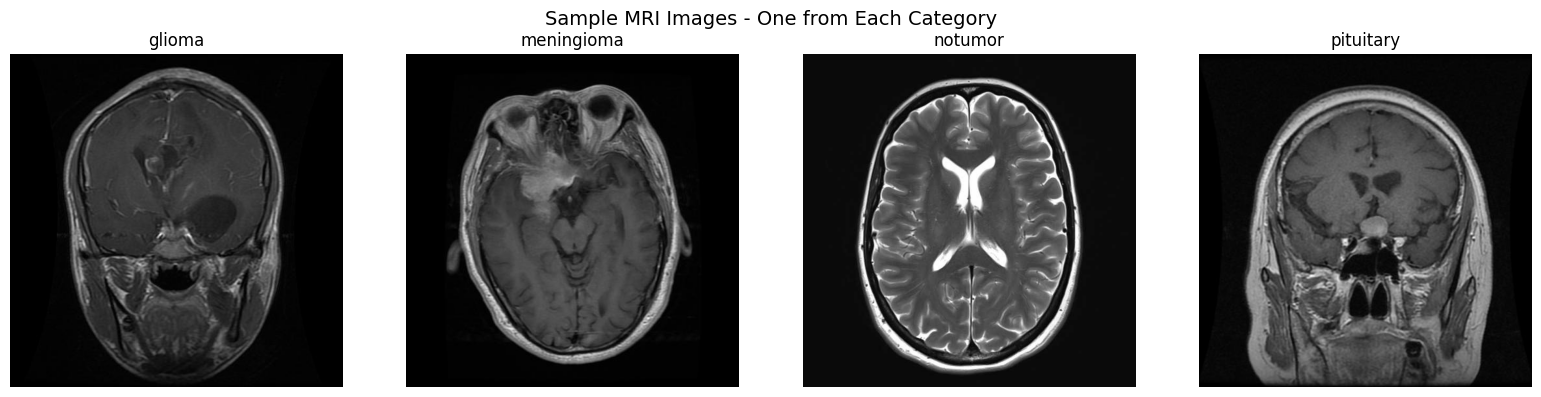

Original image size: (512, 512)
Image mode: RGB


In [5]:
# visualizing one sample MRI from each class
from PIL import Image

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, cat in enumerate(class_names):
    img_path = os.path.join('./brain-tumor-mri-dataset/Training', cat)
    img = Image.open(os.path.join(img_path, os.listdir(img_path)[5]))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(cat, fontsize=12)
    axes[i].axis('off')
plt.suptitle("Sample MRI Images - One from Each Category", fontsize=14)
plt.tight_layout()
plt.show()

# checking original image size
sample_path = './brain-tumor-mri-dataset/Training/glioma'
sample_img = Image.open(os.path.join(sample_path, os.listdir(sample_path)[0]))
print("Original image size:", sample_img.size)
print("Image mode:", sample_img.mode)

In [6]:
# loading images using ImageDataGenerator
# resizing to 128x128 for transfer learning on CPU
IMG_SIZE = 128

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    zoom_range=0.05
)

# only rescaling/preprocessing for test data
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(
    './brain-tumor-mri-dataset/Training',
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    './brain-tumor-mri-dataset/Testing',
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

print('\nClass mapping:', train_data.class_indices)

Found 5712 images belonging to 4 classes.


Found 1311 images belonging to 4 classes.



Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [7]:
# building Transfer Learning model using pre-trained MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze the pre-trained weights completely

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,868 (10.00 MB)

 Trainable params: 362,116 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

In [8]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# callbacks - reduce lr on plateau and early stopping
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1, mode='max')

# training the model
history = model.fit(train_data,
                    epochs=30,
                    validation_data=test_data,
                    callbacks=[lr_reducer, early_stop])

Epoch 1/30


  1/179 ━━━━━━━━━━━━━━━━━━━━ 10:02 3s/step - accuracy: 0.1875 - loss: 2.8262

  2/179 ━━━━━━━━━━━━━━━━━━━━ 18s 105ms/step - accuracy: 0.2344 - loss: 2.5461

  3/179 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - accuracy: 0.2431 - loss: 2.4551

  4/179 ━━━━━━━━━━━━━━━━━━━━ 23s 136ms/step - accuracy: 0.2604 - loss: 2.3538

...

177/179 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9613 - loss: 0.1008

178/179 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9613 - loss: 0.1008

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9614 - loss: 0.1008

179/179 ━━━━━━━━━━━━━━━━━━━━ 25s 138ms/step - accuracy: 0.9634 - loss: 0.0999 - val_accuracy: 0.9405 - val_loss: 0.1606 - learning_rate: 1.2500e-04


Restoring model weights from the end of the best epoch: 30.


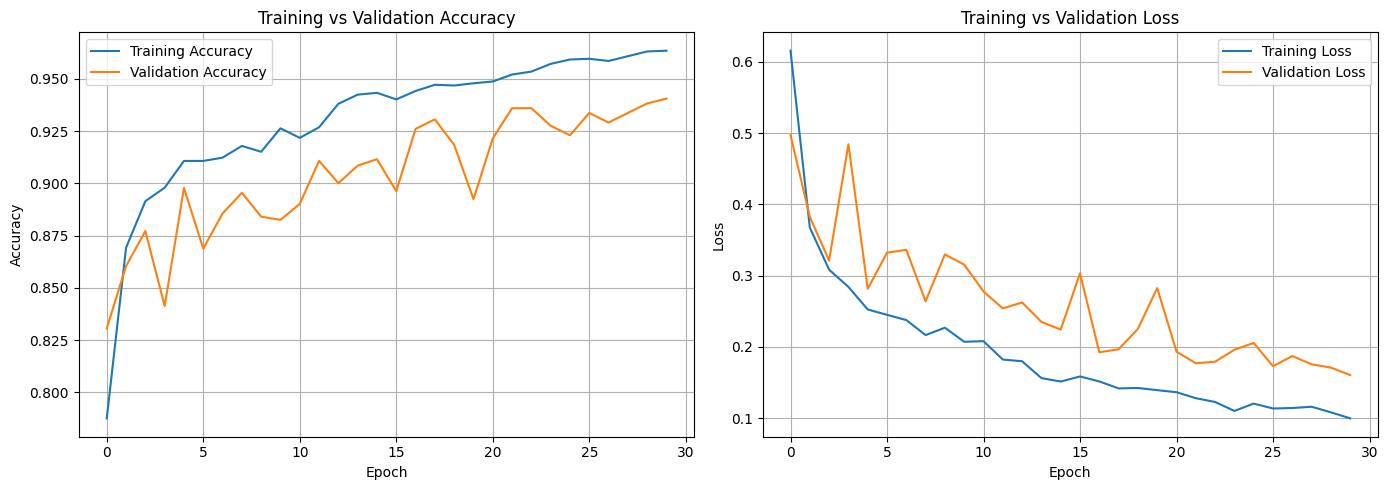


Final Training Accuracy: 96.34%
Best Validation Accuracy: 94.05%

✅ No significant overfitting - gap is only 2.29%


In [9]:
# plotting accuracy and loss curves to check for overfitting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Training vs Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Training vs Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nFinal Training Accuracy: {:.2f}%".format(history.history['accuracy'][-1] * 100))
print("Best Validation Accuracy: {:.2f}%".format(max(history.history['val_accuracy']) * 100))

gap = history.history['accuracy'][-1] - max(history.history['val_accuracy'])
if gap < 0.05:
    print("\n✅ No significant overfitting - gap is only {:.2f}%".format(gap * 100))
elif gap < 0.10:
    print("\n⚠️ Mild overfitting - gap is {:.2f}%, but val accuracy is above 90% target".format(gap * 100))
else:
    print("\n⚠️ Overfitting detected - gap is {:.2f}%".format(gap * 100))

 1/41 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.9375 - loss: 0.0922

 2/41 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.9375 - loss: 0.1391 

 3/41 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9271 - loss: 0.1617

 4/41 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9219 - loss: 0.1731

 5/41 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.9212 - loss: 0.1730

...

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9067 - loss: 0.2396

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.9405 - loss: 0.1606



Test Accuracy: 94.05%
Test Loss: 0.1606


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step


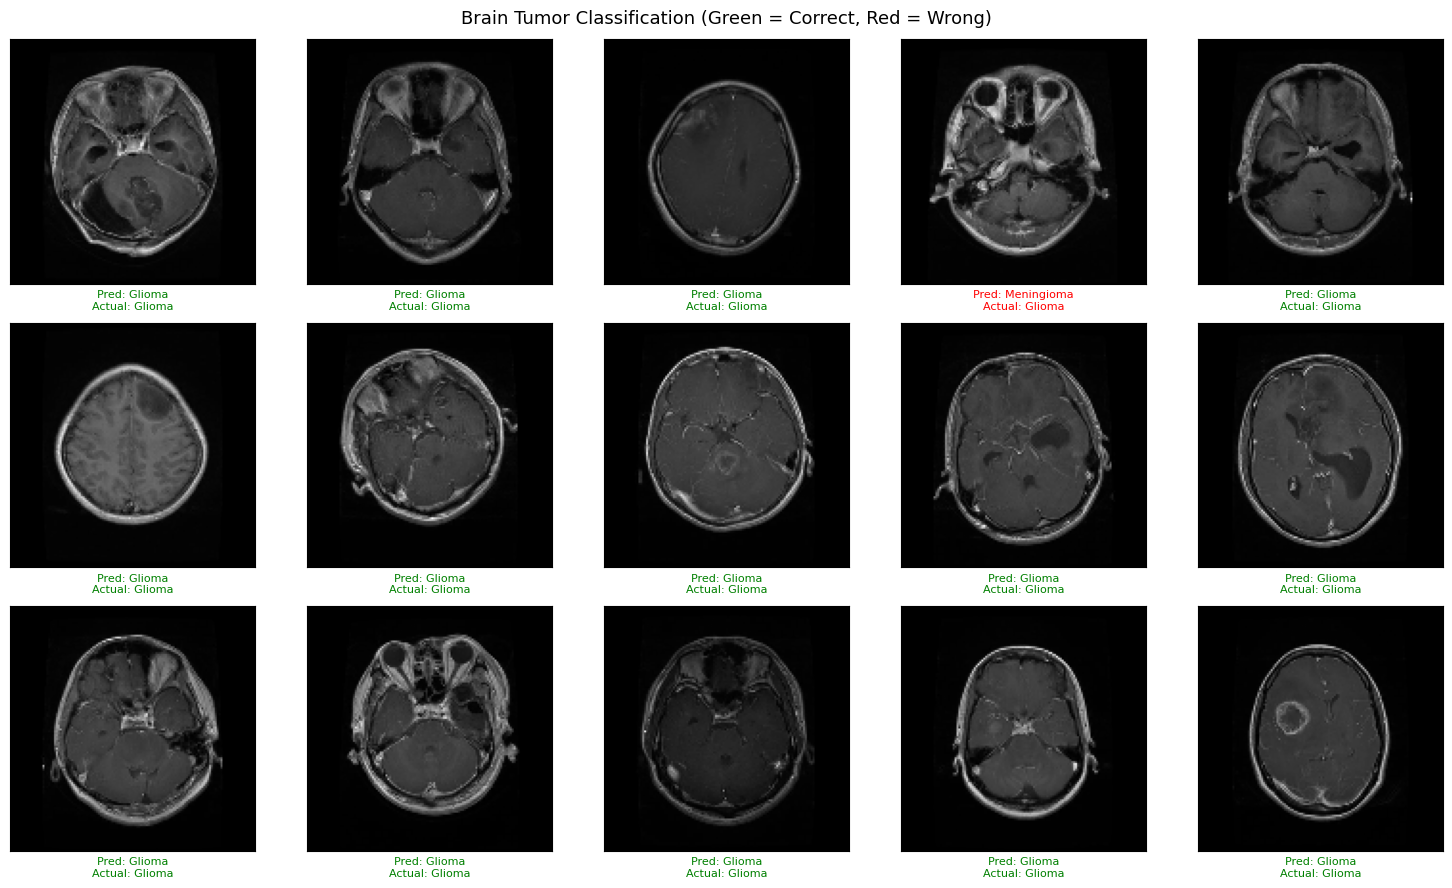

In [10]:
# evaluating on test data
test_loss, test_accuracy = model.evaluate(test_data, verbose=1)
print("\nTest Accuracy: {:.2f}%".format(test_accuracy * 100))
print("Test Loss: {:.4f}".format(test_loss))

# visualizing some predictions
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
test_data.reset()
test_images, test_labels = next(iter(test_data))
predictions = model.predict(test_images)

plt.figure(figsize=(15, 9))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow((test_images[i] + 1.0) / 2.0)
    predicted = class_names[np.argmax(predictions[i])]
    actual = class_names[int(test_labels[i])]
    color = 'green' if predicted == actual else 'red'
    plt.xlabel(f"Pred: {predicted}\nActual: {actual}", color=color, fontsize=8)
    plt.xticks([])
    plt.yticks([])
plt.suptitle("Brain Tumor Classification (Green = Correct, Red = Wrong)", fontsize=13)
plt.tight_layout()
plt.show()

Classification Report:

              precision    recall  f1-score   support

      Glioma       0.98      0.87      0.92       300
  Meningioma       0.88      0.89      0.88       306
    No Tumor       0.97      1.00      0.98       405
   Pituitary       0.92      0.99      0.95       300

    accuracy                           0.94      1311
   macro avg       0.94      0.94      0.94      1311
weighted avg       0.94      0.94      0.94      1311



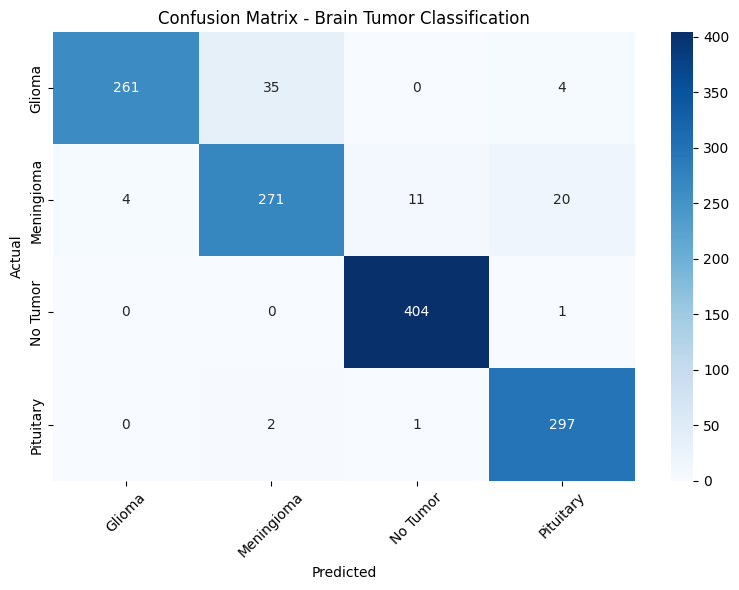


✅ Final Test Accuracy: 94.05% (Target was 90%)


In [11]:
# classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_data.reset()
y_pred = []
y_true = []

for i in range(len(test_data)):
    images, labels = test_data[i]
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.astype(int))

y_pred = np.array(y_pred)
y_true = np.array(y_true)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Brain Tumor Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ Final Test Accuracy: {:.2f}% (Target was 90%)".format(test_accuracy * 100))